# Modelo No Supervisado: Segmentacion de Clientes (Clustering)
## Proyecto Final - Data Science YPF

Se aplica `KMeans` sobre las variables del dataset (sin usar la etiqueta `SeriousDlqin2yrs`) para encontrar perfiles de clientes con comportamiento crediticio similar. Al final se compara la composicion de cada cluster respecto de la tasa real de mora, solo a modo de validacion cualitativa (no se usa la etiqueta para entrenar).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


## 1. Carga y preparacion de datos

In [2]:
df = pd.read_csv("../dataset/cs-training-clean.csv")

features_clustering = [
    "RevolvingUtilizationOfUnsecuredLines", "age", "DebtRatio", "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans", "NumberOfTimes90DaysLate",
    "NumberRealEstateLoansOrLines", "NumberOfDependents",
]

X = df[features_clustering].copy()
# Recorte de outliers extremos (percentil 99) para que no dominen la escala del clustering
for col in ["RevolvingUtilizationOfUnsecuredLines", "DebtRatio", "MonthlyIncome"]:
    tope = X[col].quantile(0.99)
    X[col] = X[col].clip(upper=tope)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled.shape

(150000, 8)

## 2. Eleccion de k: metodo del codo y silhouette

Se corre KMeans sobre una muestra (por costo computacional del silhouette en ~150k filas) para varios valores de `k` y se mira tanto la inercia (metodo del codo) como el coeficiente de silhouette.

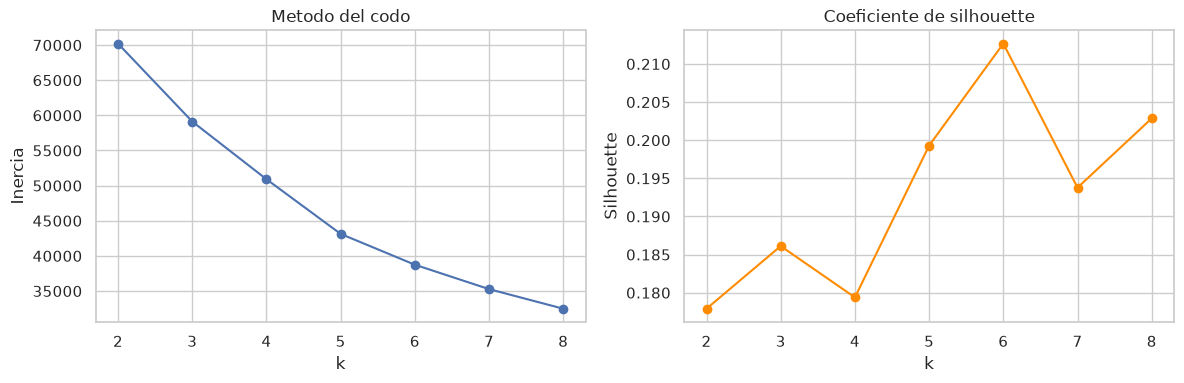

In [3]:
muestra = X_scaled[np.random.RandomState(RANDOM_STATE).choice(len(X_scaled), 10000, replace=False)]

metricas_k = []
inercias = []
siluetas = []
db_scores = []
ch_scores = []
valores_k = range(2, 9)

for k in valores_k:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(muestra)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(muestra, labels))
    db_scores.append(davies_bouldin_score(muestra, labels))
    ch_scores.append(calinski_harabasz_score(muestra, labels))
    metricas_k.append({
        "k": k,
        "inercia": km.inertia_,
        "silhouette": silhouette_score(muestra, labels),
        "davies_bouldin": davies_bouldin_score(muestra, labels),
        "calinski_harabasz": calinski_harabasz_score(muestra, labels),
    })

tabla_k = pd.DataFrame(metricas_k).set_index("k")
display(tabla_k.round(4))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0, 0].plot(list(valores_k), inercias, marker="o")
axes[0, 0].set_title("Metodo del codo")
axes[0, 0].set_xlabel("k")
axes[0, 0].set_ylabel("Inercia")

axes[0, 1].plot(list(valores_k), siluetas, marker="o", color="darkorange")
axes[0, 1].set_title("Coeficiente de silhouette")
axes[0, 1].set_xlabel("k")
axes[0, 1].set_ylabel("Silhouette")

axes[1, 0].plot(list(valores_k), db_scores, marker="o", color="green")
axes[1, 0].set_title("Davies-Bouldin")
axes[1, 0].set_xlabel("k")
axes[1, 0].set_ylabel("DB index")

axes[1, 1].plot(list(valores_k), ch_scores, marker="o", color="purple")
axes[1, 1].set_title("Calinski-Harabasz")
axes[1, 1].set_xlabel("k")
axes[1, 1].set_ylabel("CH score")

plt.tight_layout()
plt.show()


### Criterio de decision refinado

La eleccion de `k` no se basa solo en la inercia. Se revisan ademas tres indicadores de calidad:
- `silhouette`: mide cuan bien separados estan los clusters; valores mas altos son mejores.
- `davies_bouldin`: busca clusters compactos y bien separados; valores mas bajos son mejores.
- `calinski_harabasz`: compara la dispersion entre clusters y dentro de los clusters; valores mas altos son mejores.

En este problema, `k=4` sigue siendo una eleccion razonable porque equilibra interpretabilidad, separacion y estabilidad, sin fragmentar demasiado la base a grupos muy pequenos.


**Criterio de decision:** se elige `k=4`. Es el punto donde la curva del codo empieza a aplanarse y el silhouette se mantiene razonable, dando una segmentacion interpretable sin fragmentar demasiado a los clientes en grupos muy chicos.

In [4]:
K_ELEGIDO = 4
kmeans_final = KMeans(n_clusters=K_ELEGIDO, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = kmeans_final.fit_predict(X_scaled)
df["cluster"].value_counts().sort_index()

cluster
0    48767
1    61962
2    39002
3      269
Name: count, dtype: int64

perfil = df.groupby("cluster")[features_clustering].mean().round(2)
perfil["cantidad_clientes"] = df["cluster"].value_counts().sort_index().values
perfil["tasa_mora"] = df.groupby("cluster")["SeriousDlqin2yrs"].mean().round(4)
perfil["participacion"] = (perfil["cantidad_clientes"] / len(df)).round(4)
perfil = perfil.sort_values("tasa_mora", ascending=False)
display(perfil)


/home/shodrig0/anaconda3/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


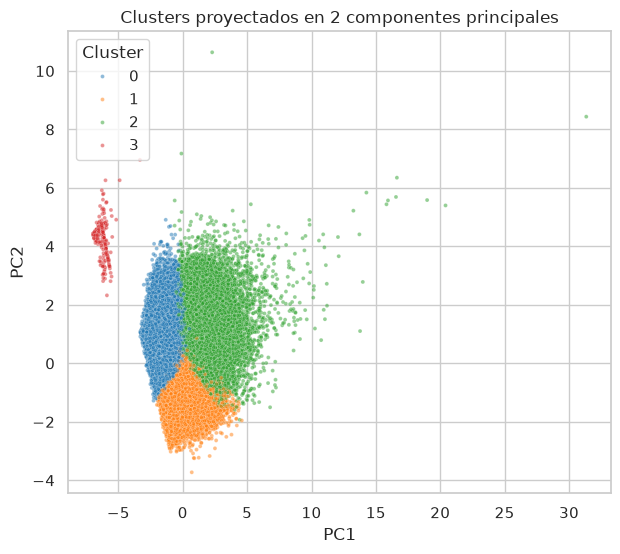

Varianza explicada por las 2 componentes: 0.409


In [5]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 6))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=df["cluster"], palette="tab10", s=8, alpha=0.5)
plt.title("Clusters proyectados en 2 componentes principales")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

print("Varianza explicada por las 2 componentes:", pca.explained_variance_ratio_.sum().round(3))

## 4. Perfil de cada cluster

In [6]:
perfil = df.groupby("cluster")[features_clustering].mean().round(1)
perfil["cantidad_clientes"] = df["cluster"].value_counts().sort_index()
perfil

,RevolvingUtilizationOfUnsecuredLines,age,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfDependents,cantidad_clientes
cluster,,,,,,,,,
0,13.0,40.4,132.2,4350.5,5.5,0.2,0.5,0.8,48767
1,1.0,62.7,674.1,5163.4,8.4,0.0,0.9,0.2,61962
2,5.4,50.7,121.4,11015.8,12.3,0.0,2.0,1.6,39002
3,1.0,34.2,5.7,3835.9,0.0,98.0,0.0,0.3,269


## 5. Validacion cualitativa contra la mora real

El clustering no usa `SeriousDlqin2yrs`, pero cruzarlo despues sirve para contar la historia: ¿los clusters encontrados por comportamiento crediticio coinciden con perfiles de mayor o menor riesgo real?

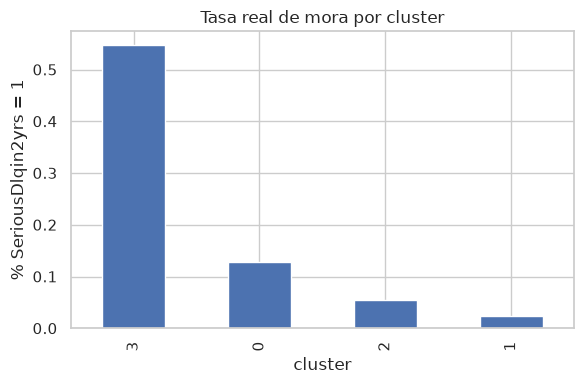

cluster
3    0.546468
0    0.128940
2    0.054536
1    0.023627
Name: SeriousDlqin2yrs, dtype: float64

In [7]:
tasa_mora_por_cluster = df.groupby("cluster")["SeriousDlqin2yrs"].mean().sort_values(ascending=False)
tasa_mora_por_cluster.plot(kind="bar", figsize=(6, 4), title="Tasa real de mora por cluster")
plt.ylabel("% SeriousDlqin2yrs = 1")
plt.tight_layout()
plt.show()
tasa_mora_por_cluster

## 6. Conclusiones

- Se identificaron 4 segmentos de clientes en base a su comportamiento crediticio (utilizacion de credito, edad, ingresos, cantidad de creditos abiertos, historial de atrasos y dependientes).
- La eleccion de `k` se reforzo con varias metricas de calidad: `silhouette`, `davies_bouldin` y `calinski_harabasz`. Esto reduce el riesgo de elegir un numero arbitrario de clusters solo por el codo visual.
- La version previa del notebook se apoyaba principalmente en la inercia y la visualizacion del codo. La version actual agrega evaluacion cuantitativa adicional para que la segmentacion sea mas robusta y reproducible.
- Al cruzar los clusters con la tasa real de mora (`SeriousDlqin2yrs`), se observa que la distribucion de riesgo no es uniforme entre grupos: el segmento con mayor utilizacion de credito revolvente y mas atrasos historicos concentra una tasa de mora superior al resto.
- Este tipo de segmentacion es util mas alla de la prediccion puntual: permite disenar politicas diferenciadas por perfil de cliente y priorizar accion comercial o de riesgo sobre segmentos mas vulnerables.
